# E-Commerce Sales And Customer Analysis

## Problem Statements:
An e-commerce company wants to understand its sales performance, customer behavior, product profitability, and regional trends to improve decision-making.

## Objectives

- Clean and prepare the dataset
- Perform exploratory data analysis (EDA)
- Generate business insights
- Export cleaned data for SQL and Power BI

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/store_sales_data.csv")

## Dataset Overview


In [3]:
df.head()

,Customer ID,Customer Name,Last Name,Date of Birth,Sales,Year,Outlet Type,City Type,Category of Goods,Region,Country,Segment,Sales Date,Order ID,Order Date,Ship Date,Ship Mode,State,Postal Code,Product ID,Sub-Category,Product Name,Quantity,Discount,Profit
0,CUST000001,Curtis,Krause,1973-11-29,3344.69,2023,Large,Tier 1,Fast Food,East,India,Consumer,2023-03-11,ORD000001,2020-04-13,2020-04-18,Same Day,West Bengal,700001,PROD000001,Burgers,Burgers - 718,3,0.09,448.24
1,CUST000002,Jeremy,Foster,1987-08-30,37094.41,2022,Medium,Tier 2,Fast Food,East,India,Corporate,2023-09-09,ORD000002,2021-01-08,2021-01-11,Standard Class,Punjab,160001,PROD000002,Pizzas,Pizzas - 519,5,0.39,3134.34
2,CUST000003,Ariel,Mccann,1980-12-15,35501.08,2023,Large,Village,Electric Appliances,South,India,Consumer,2022-08-15,ORD000003,2020-08-11,2020-08-16,Second Class,Gujarat,380001,PROD000003,Fans,Fans - 395,6,0.07,8324.21
3,CUST000004,Colleen,Maynard,1989-05-23,8969.33,2021,Medium,Village,Dairy Products,East,India,Corporate,2021-01-23,ORD000004,2021-10-10,2021-10-16,First Class,West Bengal,700001,PROD000004,Milk,Milk - 798,4,0.18,1962.66
4,CUST000005,Gina,Holden,1957-12-31,35530.44,2021,Small,Village,Sessional Fruits & Vegetables,West,India,Consumer,2020-12-24,ORD000005,2019-01-22,2019-01-25,Standard Class,Delhi,110001,PROD000005,Tomatoes,Tomatoes - 442,4,0.27,2843.93


In [4]:
df.tail()

,Customer ID,Customer Name,Last Name,Date of Birth,Sales,Year,Outlet Type,City Type,Category of Goods,Region,Country,Segment,Sales Date,Order ID,Order Date,Ship Date,Ship Mode,State,Postal Code,Product ID,Sub-Category,Product Name,Quantity,Discount,Profit
99995,CUST099996,Thomas,Adams,2018-02-02,254.35,2020,Large,Tier 1,Furniture,East,India,Corporate,2019-08-05,ORD099996,2019-01-31,2019-02-05,First Class,Gujarat,380001,PROD099996,Beds,Beds - 169,2,0.12,61.84
99996,CUST099997,Clifford,Dillon,1955-08-11,846.66,2019,Medium,Tier 2,Sessional Fruits & Vegetables,North,India,Corporate,2019-01-24,ORD099997,2020-04-02,2020-04-09,Same Day,Rajasthan,302001,PROD099997,Tomatoes,Tomatoes - 291,1,0.43,118.60
99997,CUST099998,Kelly,Deleon,1991-02-27,12165.34,2019,Large,Tier 2,Furniture,East,India,Consumer,2019-03-10,ORD099998,2021-06-27,2021-07-02,Standard Class,Maharashtra,400001,PROD099998,Chairs,Chairs - 381,4,0.13,2100.20
99998,CUST099999,Katie,Moses,1990-10-21,41242.99,2019,Small,Tier 1,Fast Food,North,India,Consumer,2023-11-29,ORD099999,2019-07-27,2019-08-01,Second Class,Karnataka,560001,PROD099999,Sandwiches,Sandwiches - 961,4,0.41,4674.57
99999,CUST100000,Jeremy,Combs,2016-12-27,47402.45,2019,Medium,Village,Fast Food,North,India,Corporate,2020-07-02,ORD100000,2020-02-20,2020-02-24,Same Day,Maharashtra,400001,PROD100000,Burgers,Burgers - 611,5,0.32,8490.54


In [5]:
df.sample(10)

,Customer ID,Customer Name,Last Name,Date of Birth,Sales,Year,Outlet Type,City Type,Category of Goods,Region,Country,Segment,Sales Date,Order ID,Order Date,Ship Date,Ship Mode,State,Postal Code,Product ID,Sub-Category,Product Name,Quantity,Discount,Profit
20988,CUST020989,Jill,Bryant,2000-08-18,8005.73,2023,Large,Tier 2,Electric Appliances,East,India,Corporate,2023-10-22,ORD020989,2019-02-06,2019-02-10,Second Class,Punjab,160001,PROD020989,Refrigerators,Refrigerators - 655,6,0.03,1021.61
74890,CUST074891,Eric,Larson,1968-04-08,44953.78,2021,Medium,Tier 1,Furniture,West,India,Corporate,2023-01-10,ORD074891,2021-08-16,2021-08-22,First Class,Delhi,110001,PROD074891,Beds,Beds - 256,10,0.45,7260.62
48852,CUST048853,Maureen,Johnson,1963-04-07,46804.02,2021,Small,Tier 1,Fast Food,North,India,Consumer,2022-12-10,ORD048853,2019-05-13,2019-05-19,Standard Class,Madhya Pradesh,462001,PROD048853,Burgers,Burgers - 210,9,0.12,6755.79
41314,CUST041315,Tamara,Rowe,1993-11-24,6083.01,2020,Large,Village,Dairy Products,North,India,Consumer,2019-06-02,ORD041315,2022-12-26,2022-12-27,Standard Class,Gujarat,380001,PROD041315,Milk,Milk - 199,5,0.18,810.30
37432,CUST037433,Luke,Moran,1965-06-13,529.11,2020,Large,Village,Sessional Fruits & Vegetables,North,India,Corporate,2023-01-10,ORD037433,2021-04-22,2021-04-25,Second Class,Uttar Pradesh,226001,PROD037433,Tomatoes,Tomatoes - 935,2,0.46,84.47
19632,CUST019633,Jason,Spears,2007-05-11,5178.49,2023,Small,Tier 2,Household Items,South,India,Consumer,2023-06-25,ORD019633,2022-12-19,2022-12-22,Standard Class,Gujarat,380001,PROD019633,Detergents,Detergents - 218,10,0.12,675.09
96819,CUST096820,Madeline,Ho,1975-12-11,27211.46,2019,Small,Tier 1,Dairy Products,East,India,Consumer,2019-04-28,ORD096820,2020-11-11,2020-11-16,Standard Class,Rajasthan,302001,PROD096820,Yogurt,Yogurt - 212,7,0.42,2237.49
84349,CUST084350,Jeremy,Smith,1977-11-28,31565.08,2023,Small,Tier 2,Electric Appliances,East,India,Corporate,2023-02-24,ORD084350,2021-06-12,2021-06-14,First Class,West Bengal,700001,PROD084350,Refrigerators,Refrigerators - 295,6,0.47,4143.56
79238,CUST079239,Richard,Conrad,2014-10-15,36407.00,2022,Medium,Tier 2,Dairy Products,East,India,Consumer,2023-02-10,ORD079239,2023-05-18,2023-05-19,Same Day,Madhya Pradesh,462001,PROD079239,Milk,Milk - 843,10,0.48,2152.41
54690,CUST054691,Sara,Rodriguez,2015-12-15,10452.48,2022,Large,Tier 1,Sessional Fruits & Vegetables,East,India,Consumer,2022-01-19,ORD054691,2019-08-15,2019-08-22,Standard Class,Punjab,160001,PROD054691,Mangoes,Mangoes - 942,6,0.41,1063.36


## Dataset Structure

In [6]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 100000
Number of Columns: 25


In [7]:
df.columns

Index(['Customer ID', 'Customer Name', 'Last Name', 'Date of Birth', 'Sales',
       'Year', 'Outlet Type', 'City Type', 'Category of Goods', 'Region',
       'Country', 'Segment', 'Sales Date', 'Order ID', 'Order Date',
       'Ship Date', 'Ship Mode', 'State', 'Postal Code', 'Product ID',
       'Sub-Category', 'Product Name', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Customer ID        100000 non-null  object 
 1   Customer Name      100000 non-null  object 
 2   Last Name          100000 non-null  object 
 3   Date of Birth      100000 non-null  object 
 4   Sales              100000 non-null  float64
 5   Year               100000 non-null  int64  
 6   Outlet Type        100000 non-null  object 
 7   City Type          100000 non-null  object 
 8   Category of Goods  100000 non-null  object 
 9   Region             100000 non-null  object 
 10  Country            100000 non-null  object 
 11  Segment            100000 non-null  object 
 12  Sales Date         100000 non-null  object 
 13  Order ID           100000 non-null  object 
 14  Order Date         100000 non-null  object 
 15  Ship Date          100000 non-null  object 
 16  Shi

In [9]:
df.describe()

,Sales,Year,Postal Code,Quantity,Discount,Profit
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,25084.410142,2020.999910,388985.180000,5.493760,0.251320,3755.305114
std,14403.187686,1.413757,184192.704685,2.876102,0.144324,2639.852035
min,100.570000,2019.000000,110001.000000,1.000000,0.000000,6.520000
25%,12618.030000,2020.000000,226001.000000,3.000000,0.130000,1651.105000
50%,25134.695000,2021.000000,380001.000000,5.000000,0.250000,3317.450000
75%,37575.850000,2022.000000,560001.000000,8.000000,0.380000,5363.845000
max,49999.890000,2023.000000,700001.000000,10.000000,0.500000,14563.670000


## Data Quality Assessment

In [10]:
df.isnull().sum()

Customer ID          0
Customer Name        0
Last Name            0
Date of Birth        0
Sales                0
Year                 0
Outlet Type          0
City Type            0
Category of Goods    0
Region               0
Country              0
Segment              0
Sales Date           0
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
State                0
Postal Code          0
Product ID           0
Sub-Category         0
Product Name         0
Quantity             0
Discount             0
Profit               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

Customer ID          100000
Customer Name           690
Last Name              1000
Date of Birth         24536
Sales                 98976
Year                      5
Outlet Type               3
City Type                 3
Category of Goods         6
Region                    4
Country                   1
Segment                   2
Sales Date             1826
Order ID             100000
Order Date             1826
Ship Date              1832
Ship Mode                 4
State                    10
Postal Code              10
Product ID           100000
Sub-Category             24
Product Name          21365
Quantity                 10
Discount                 51
Profit                94247
dtype: int64

In [13]:
df.dtypes

Customer ID           object
Customer Name         object
Last Name             object
Date of Birth         object
Sales                float64
Year                   int64
Outlet Type           object
City Type             object
Category of Goods     object
Region                object
Country               object
Segment               object
Sales Date            object
Order ID              object
Order Date            object
Ship Date             object
Ship Mode             object
State                 object
Postal Code            int64
Product ID            object
Sub-Category          object
Product Name          object
Quantity               int64
Discount             float64
Profit               float64
dtype: object

In [14]:
df.memory_usage(deep=True)

Index                    132
Customer ID          5900000
Customer Name        5503297
Last Name            5506963
Date of Birth        5900000
Sales                 800000
Year                  800000
Outlet Type          5433512
City Type            5533055
Category of Goods    6485225
Region               5350074
Country              5400000
Segment              5749869
Sales Date           5900000
Order ID             5800000
Order Date           5900000
Ship Date            5900000
Ship Mode            6024836
State                5849101
Postal Code           800000
Product ID           5900000
Sub-Category         5611853
Product Name         6211853
Quantity              800000
Discount              800000
Profit                800000
dtype: int64

In [15]:
df.select_dtypes(include="number").columns

Index(['Sales', 'Year', 'Postal Code', 'Quantity', 'Discount', 'Profit'], dtype='object')

In [16]:
df.select_dtypes(include="object").columns

Index(['Customer ID', 'Customer Name', 'Last Name', 'Date of Birth',
       'Outlet Type', 'City Type', 'Category of Goods', 'Region', 'Country',
       'Segment', 'Sales Date', 'Order ID', 'Order Date', 'Ship Date',
       'Ship Mode', 'State', 'Product ID', 'Sub-Category', 'Product Name'],
      dtype='object')

In [17]:
(df == "").sum()

Customer ID          0
Customer Name        0
Last Name            0
Date of Birth        0
Sales                0
Year                 0
Outlet Type          0
City Type            0
Category of Goods    0
Region               0
Country              0
Segment              0
Sales Date           0
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
State                0
Postal Code          0
Product ID           0
Sub-Category         0
Product Name         0
Quantity             0
Discount             0
Profit               0
dtype: int64

In [18]:
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2020-04-13,2020-04-18
1,2021-01-08,2021-01-11
2,2020-08-11,2020-08-16
3,2021-10-10,2021-10-16
4,2019-01-22,2019-01-25


# Data Cleaning


In [19]:
date_columns = [
    "Date of Birth",
    "Sales Date",
    "Order Date",
    "Ship Date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Customer ID        100000 non-null  object        
 1   Customer Name      100000 non-null  object        
 2   Last Name          100000 non-null  object        
 3   Date of Birth      100000 non-null  datetime64[ns]
 4   Sales              100000 non-null  float64       
 5   Year               100000 non-null  int64         
 6   Outlet Type        100000 non-null  object        
 7   City Type          100000 non-null  object        
 8   Category of Goods  100000 non-null  object        
 9   Region             100000 non-null  object        
 10  Country            100000 non-null  object        
 11  Segment            100000 non-null  object        
 12  Sales Date         100000 non-null  datetime64[ns]
 13  Order ID           100000 non-null  object   

# Feature Engineering


In [20]:
from datetime import datetime

today = pd.Timestamp.today()

df["Age"] = ((today - df["Date of Birth"]).dt.days // 365)

df[["Date of Birth", "Age"]].head()

,Date of Birth,Age
0,1973-11-29,52
1,1987-08-30,38
2,1980-12-15,45
3,1989-05-23,37
4,1957-12-31,68


In [21]:
def age_group(age):
    if age < 18:
        return "<18"
    elif age <= 25:
        return "18-25"
    elif age <= 35:
        return "26-35"
    elif age <= 45:
        return "36-45"
    elif age <= 60:
        return "46-60"
    else:
        return "60+"

df["Age Group"] = df["Age"].apply(age_group)

df[["Age", "Age Group"]].head()

,Age,Age Group
0,52,46-60
1,38,36-45
2,45,36-45
3,37,36-45
4,68,60+


In [22]:
df["Delivery Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Delivery Days"]].head()

,Order Date,Ship Date,Delivery Days
0,2020-04-13,2020-04-18,5
1,2021-01-08,2021-01-11,3
2,2020-08-11,2020-08-16,5
3,2021-10-10,2021-10-16,6
4,2019-01-22,2019-01-25,3


In [23]:
df["Profit Margin (%)"] = (df["Profit"] / df["Sales"]) * 100

df[["Sales", "Profit", "Profit Margin (%)"]].head()

,Sales,Profit,Profit Margin (%)
0,3344.69,448.24,13.401541
1,37094.41,3134.34,8.449629
2,35501.08,8324.21,23.447766
3,8969.33,1962.66,21.881902
4,35530.44,2843.93,8.004207


In [24]:
df["Average Selling Price"] = df["Sales"] / df["Quantity"]

df[["Sales", "Quantity", "Average Selling Price"]].head()

,Sales,Quantity,Average Selling Price
0,3344.69,3,1114.896667
1,37094.41,5,7418.882000
2,35501.08,6,5916.846667
3,8969.33,4,2242.332500
4,35530.44,4,8882.610000


In [25]:
new_columns = [
    "Age",
    "Age Group",
    "Delivery Days",
    "Profit Margin (%)",
    "Average Selling Price"
]

df[new_columns].head()

,Age,Age Group,Delivery Days,Profit Margin (%),Average Selling Price
0,52,46-60,5,13.401541,1114.896667
1,38,36-45,3,8.449629,7418.882000
2,45,36-45,5,23.447766,5916.846667
3,37,36-45,6,21.881902,2242.332500
4,68,60+,3,8.004207,8882.610000


# Exploratory Data Analysis (EDA)


## Sales Analysis


In [26]:
total_sales = df["Sales"].sum()

print(f"Total Sales : ₹{total_sales:,.2f}")

Total Sales : ₹2,508,441,014.18


In [27]:
total_profit = df["Profit"].sum()

print(f"Total Profit : ₹{total_profit:,.2f}")

Total Profit : ₹375,530,511.43


In [28]:
total_orders = df["Order ID"].nunique()

print(f"Total Orders : {total_orders}")

Total Orders : 100000


In [29]:
total_customers = df["Customer ID"].nunique()

print(f"Total Customers : {total_customers}")

Total Customers : 100000


In [30]:
average_order_value = total_sales / total_orders

print(f"Average Order Value : ₹{average_order_value:,.2f}")

Average Order Value : ₹25,084.41


In [31]:
average_profit_order = total_profit / total_orders

print(f"Average Profit per Order : ₹{average_profit_order:,.2f}")

Average Profit per Order : ₹3,755.31


### Monthly Sales Trend


In [32]:
df["Year Month"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Year Month")["Sales"].sum().reset_index()

In [33]:
df.columns.tolist()

['Customer ID',
 'Customer Name',
 'Last Name',
 'Date of Birth',
 'Sales',
 'Year',
 'Outlet Type',
 'City Type',
 'Category of Goods',
 'Region',
 'Country',
 'Segment',
 'Sales Date',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'State',
 'Postal Code',
 'Product ID',
 'Sub-Category',
 'Product Name',
 'Quantity',
 'Discount',
 'Profit',
 'Age',
 'Age Group',
 'Delivery Days',
 'Profit Margin (%)',
 'Average Selling Price',
 'Year Month']

In [34]:
df["Month"] = df["Order Date"].dt.month_name()

In [35]:
df.columns.tolist()

['Customer ID',
 'Customer Name',
 'Last Name',
 'Date of Birth',
 'Sales',
 'Year',
 'Outlet Type',
 'City Type',
 'Category of Goods',
 'Region',
 'Country',
 'Segment',
 'Sales Date',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'State',
 'Postal Code',
 'Product ID',
 'Sub-Category',
 'Product Name',
 'Quantity',
 'Discount',
 'Profit',
 'Age',
 'Age Group',
 'Delivery Days',
 'Profit Margin (%)',
 'Average Selling Price',
 'Year Month',
 'Month']

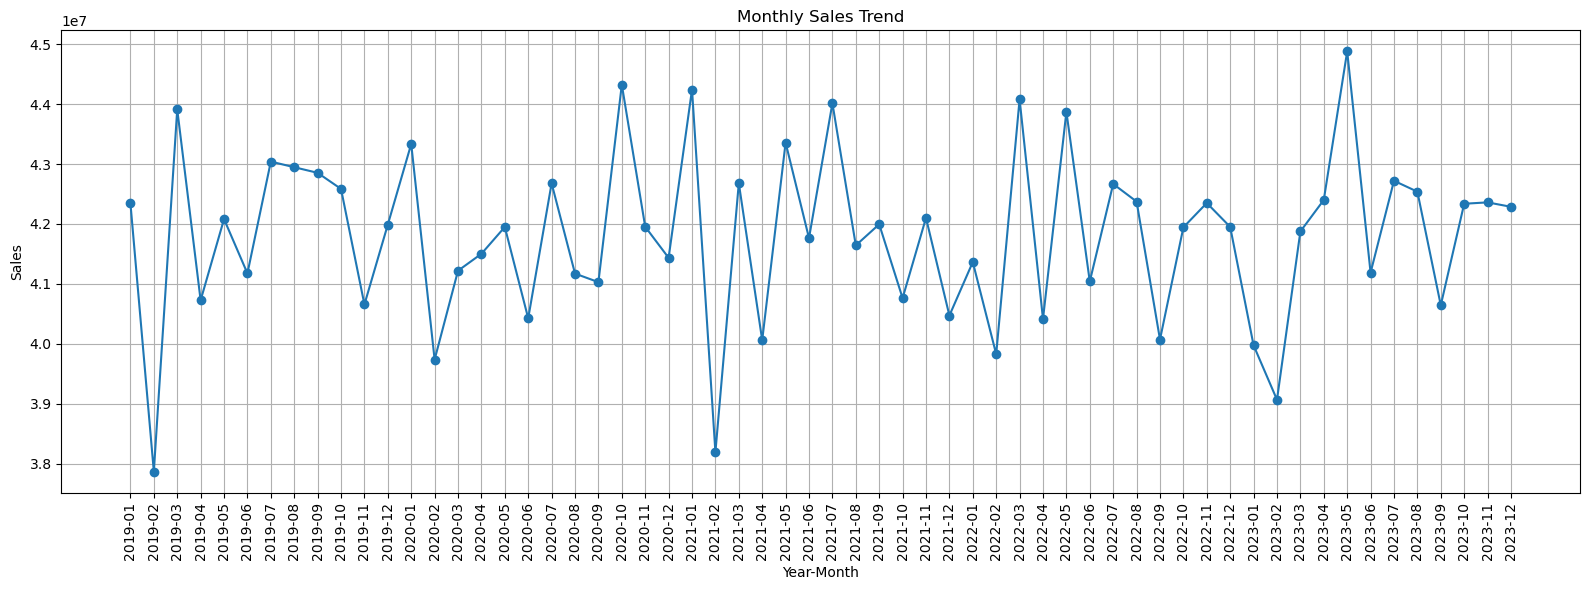

In [36]:
plt.figure(figsize=(16,6))

plt.plot(monthly_sales["Year Month"],
         monthly_sales["Sales"],
         marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.grid(True)

plt.tight_layout()

plt.show()

### Sales by Region


In [37]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

Region
East     6.353223e+08
South    6.290598e+08
North    6.244511e+08
West     6.196078e+08
Name: Sales, dtype: float64

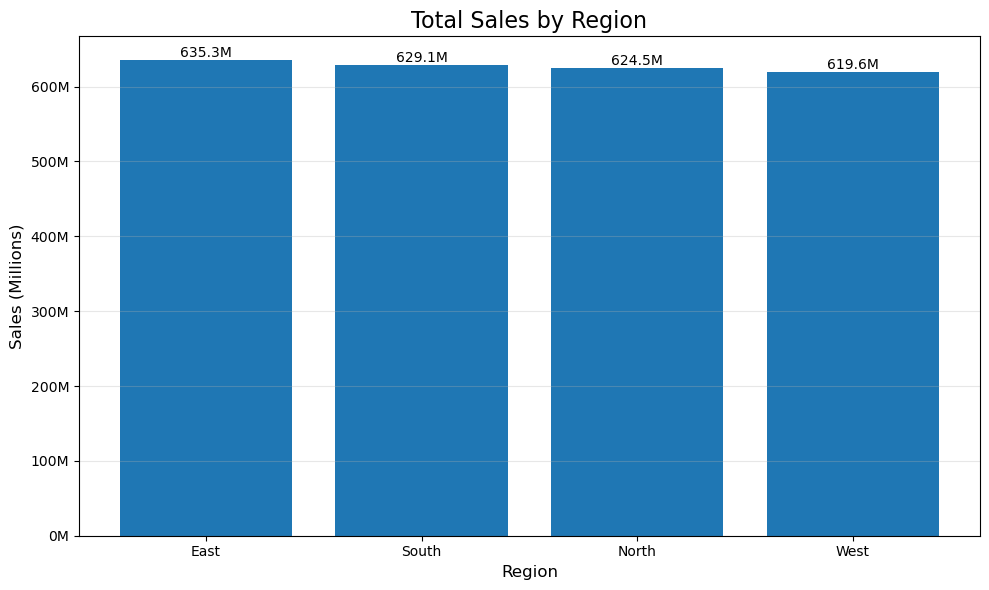

In [38]:
plt.figure(figsize=(10,6))

bars = plt.bar(region_sales.index, region_sales.values)

plt.title("Total Sales by Region", fontsize=16)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Sales (Millions)", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Sales by Category


In [39]:
category_sales = df.groupby("Category of Goods")["Sales"].sum().sort_values(ascending=False)

category_sales

Category of Goods
Sessional Fruits & Vegetables    4.199427e+08
Household Items                  4.197889e+08
Electric Appliances              4.188296e+08
Dairy Products                   4.180117e+08
Fast Food                        4.178508e+08
Furniture                        4.140173e+08
Name: Sales, dtype: float64

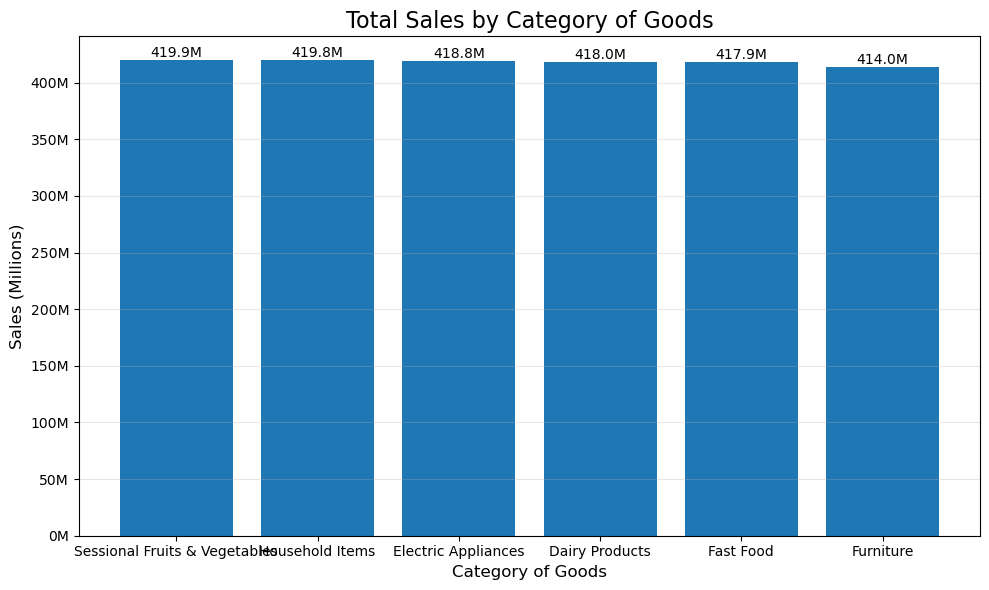

In [40]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Total Sales by Category of Goods", fontsize=16)
plt.xlabel("Category of Goods", fontsize=12)
plt.ylabel("Sales (Millions)", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Sales by Customer Segment


In [41]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

segment_sales

Segment
Corporate    1.255144e+09
Consumer     1.253297e+09
Name: Sales, dtype: float64

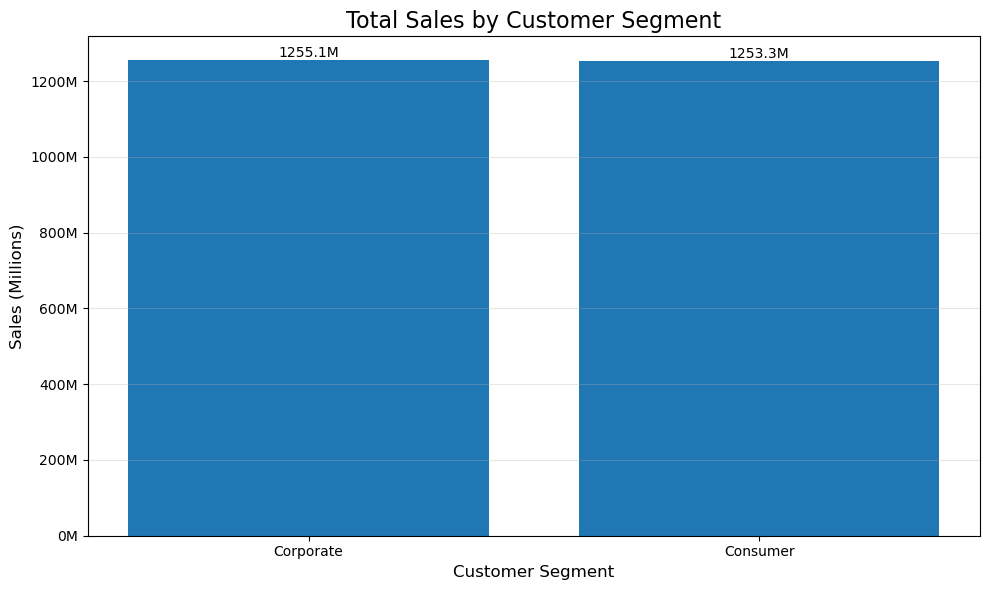

In [42]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    segment_sales.index,
    segment_sales.values
)

plt.title("Total Sales by Customer Segment", fontsize=16)
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Sales (Millions)", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Sales by Outlet Type


In [43]:
outlet_sales = df.groupby("Outlet Type")["Sales"].sum().sort_values(ascending=False)

outlet_sales

Outlet Type
Large     8.410191e+08
Medium    8.409498e+08
Small     8.264721e+08
Name: Sales, dtype: float64

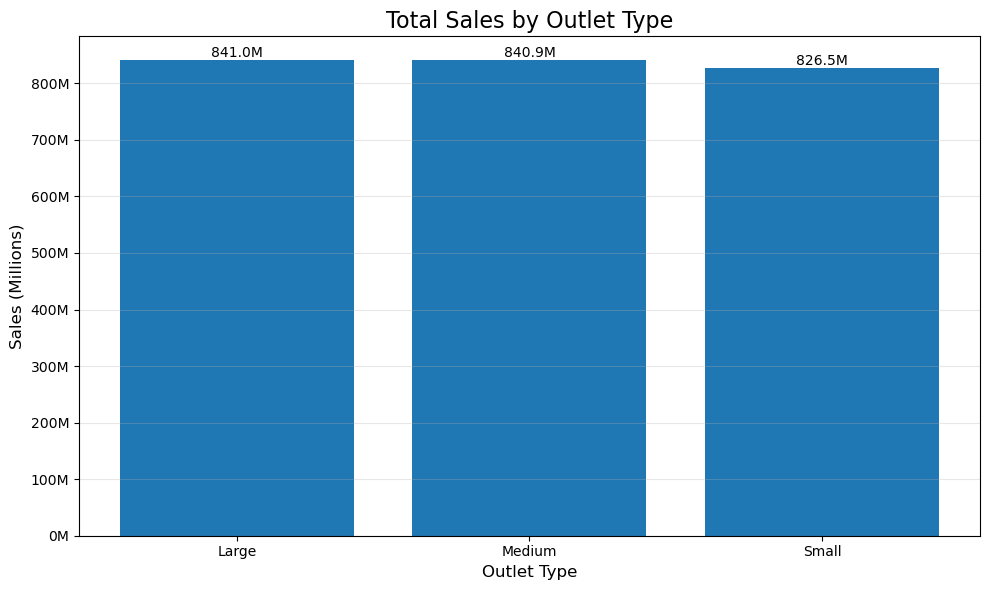

In [44]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    outlet_sales.index,
    outlet_sales.values
)

plt.title("Total Sales by Outlet Type", fontsize=16)
plt.xlabel("Outlet Type", fontsize=12)
plt.ylabel("Sales (Millions)", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Sales by City Type


In [45]:
city_sales = df.groupby("City Type")["Sales"].sum().sort_values(ascending=False)

city_sales

City Type
Tier 1     8.444204e+08
Tier 2     8.354358e+08
Village    8.285848e+08
Name: Sales, dtype: float64

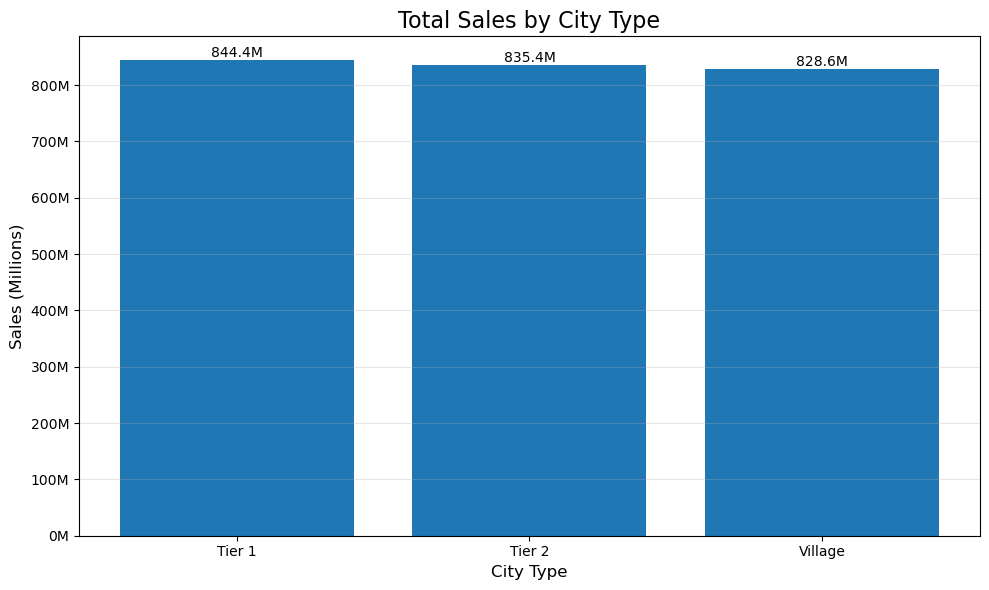

In [46]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    city_sales.index,
    city_sales.values
)

plt.title("Total Sales by City Type", fontsize=16)
plt.xlabel("City Type", fontsize=12)
plt.ylabel("Sales (Millions)", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Sales by State


In [47]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)   

state_sales

State
Rajasthan         2.558547e+08
Punjab            2.539883e+08
Maharashtra       2.523818e+08
Madhya Pradesh    2.515571e+08
West Bengal       2.507483e+08
Delhi             2.502489e+08
Karnataka         2.499100e+08
Tamil Nadu        2.493811e+08
Gujarat           2.490540e+08
Uttar Pradesh     2.453169e+08
Name: Sales, dtype: float64

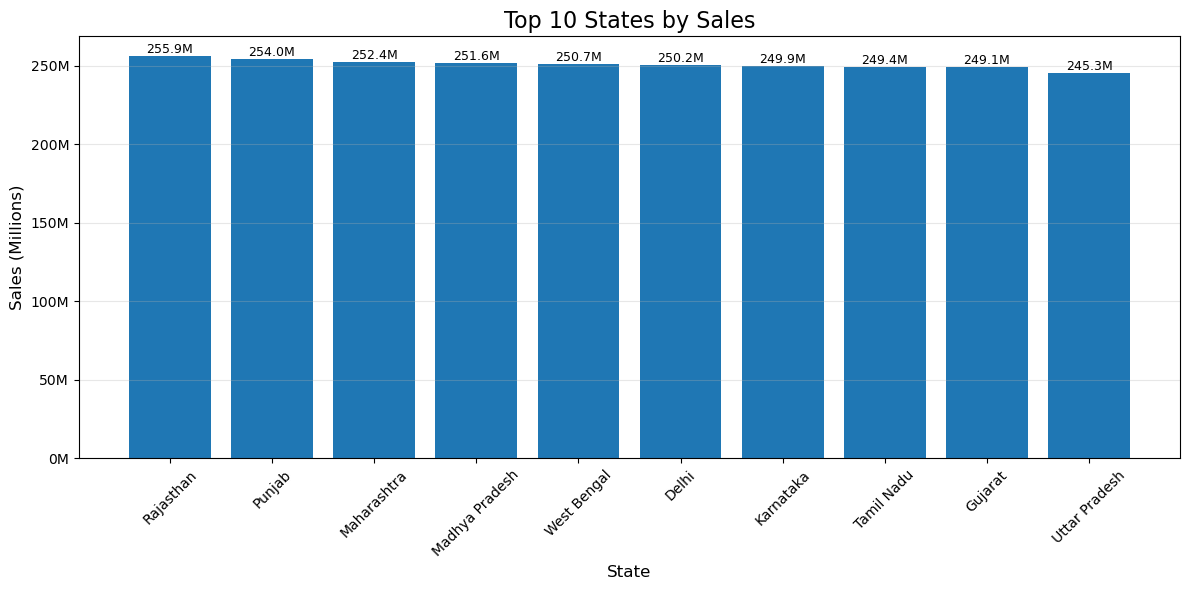

In [48]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    state_sales.index,
    state_sales.values
)

plt.title("Top 10 States by Sales", fontsize=16)
plt.xlabel("State", fontsize=12)
plt.ylabel("Sales (Millions)", fontsize=12)

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Top 10 Products by Sales


In [49]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products

Product Name
Beds - 120             467564.82
Refrigerators - 338    463807.16
Butter - 951           458374.84
Mops - 693             418713.15
Burgers - 729          408224.56
Fans - 611             402263.31
Mangoes - 912          402158.97
Apples - 425           379721.59
Milk - 660             373800.17
Refrigerators - 709    373166.48
Name: Sales, dtype: float64

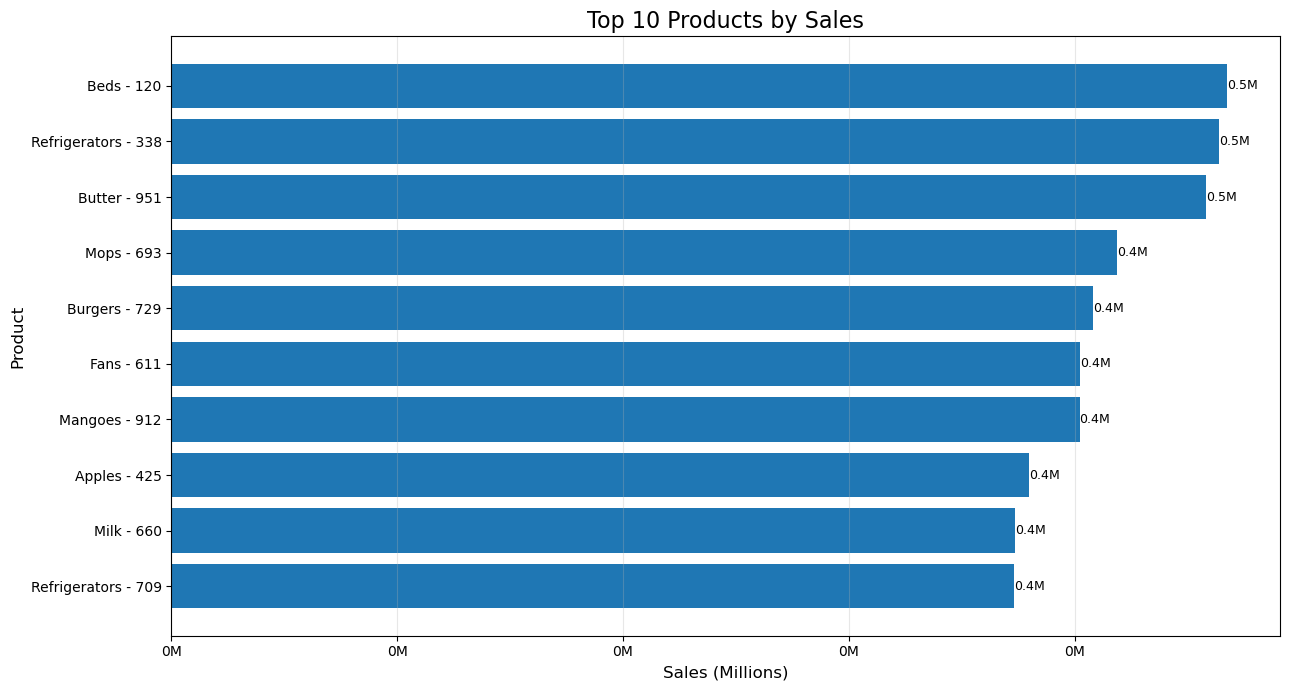

In [50]:
plt.figure(figsize=(13,7))

bars = plt.barh(
    top_products.index,
    top_products.values
)

plt.title("Top 10 Products by Sales", fontsize=16)
plt.xlabel("Sales (Millions)", fontsize=12)
plt.ylabel("Product", fontsize=12)

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

plt.gca().invert_yaxis()

for bar in bars:

    width = bar.get_width()

    plt.text(
        width,
        bar.get_y()+bar.get_height()/2,
        f"{width/1e6:.1f}M",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Top 10 Customers by Sales


In [51]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_customers

Customer Name
Michael        58499915.92
James          39171310.28
David          38902696.83
Jennifer       38093682.26
Christopher    35774989.50
John           34964016.09
Robert         34606925.16
William        24507201.77
Matthew        24489941.53
Jessica        24387119.17
Name: Sales, dtype: float64

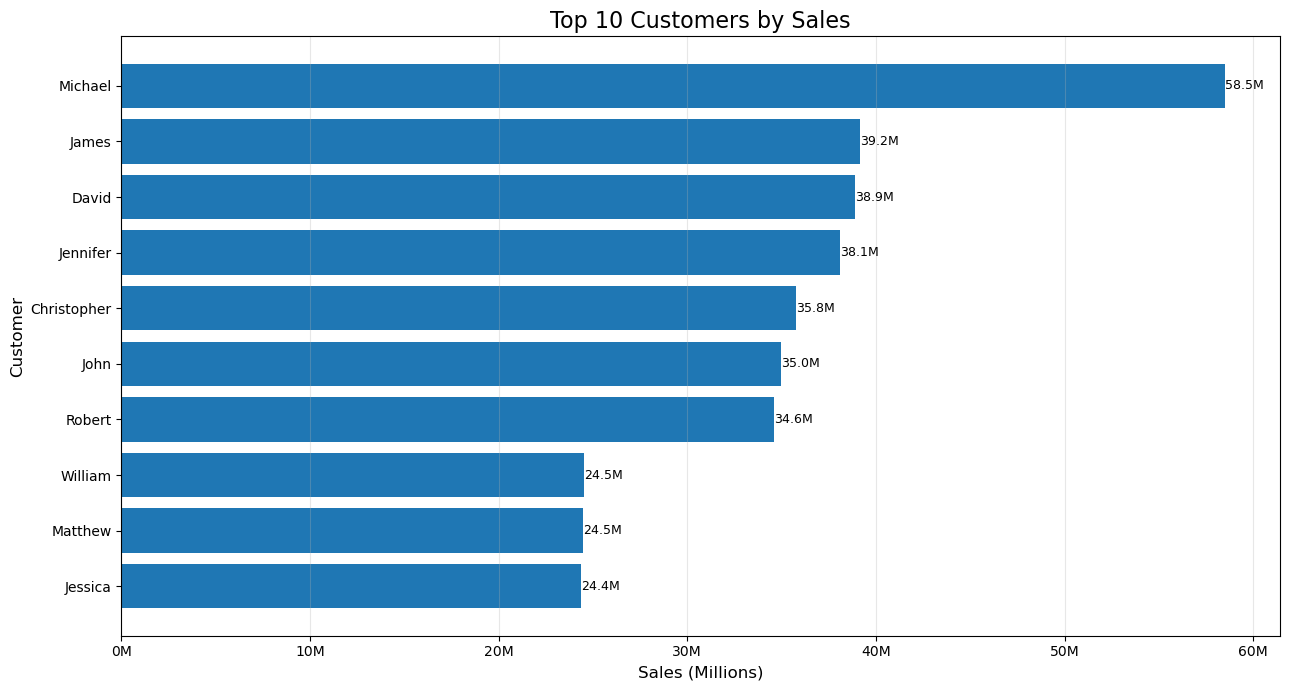

In [52]:
plt.figure(figsize=(13,7))

bars = plt.barh(
    top_customers.index,
    top_customers.values
)

plt.title("Top 10 Customers by Sales", fontsize=16)
plt.xlabel("Sales (Millions)", fontsize=12)
plt.ylabel("Customer", fontsize=12)

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

plt.gca().invert_yaxis()

for bar in bars:

    width = bar.get_width()

    plt.text(
        width,
        bar.get_y()+bar.get_height()/2,
        f"{width/1e6:.1f}M",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Profit by Region


In [53]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

region_profit

Region
East     95147250.29
South    94220596.30
North    93099384.98
West     93063279.86
Name: Profit, dtype: float64

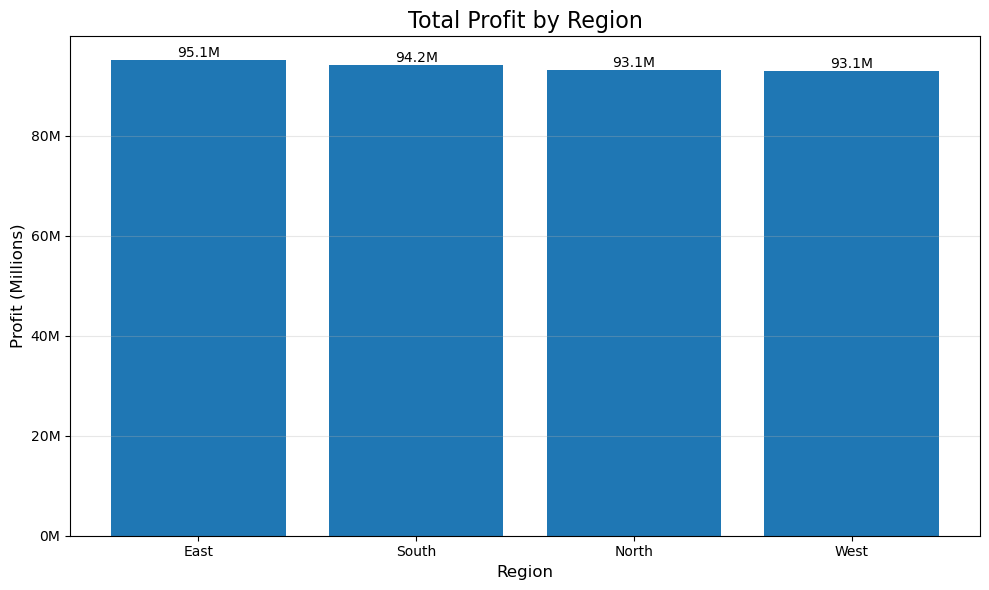

In [54]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    region_profit.index,
    region_profit.values
)

plt.title("Total Profit by Region", fontsize=16)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Profit (Millions)", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Profit by Category of Goods


In [55]:
category_profit = df.groupby("Category of Goods")["Profit"].sum().sort_values(ascending=False)

category_profit

Category of Goods
Household Items                  62871293.87
Fast Food                        62787837.10
Sessional Fruits & Vegetables    62766851.82
Electric Appliances              62702992.93
Dairy Products                   62592431.61
Furniture                        61809104.10
Name: Profit, dtype: float64

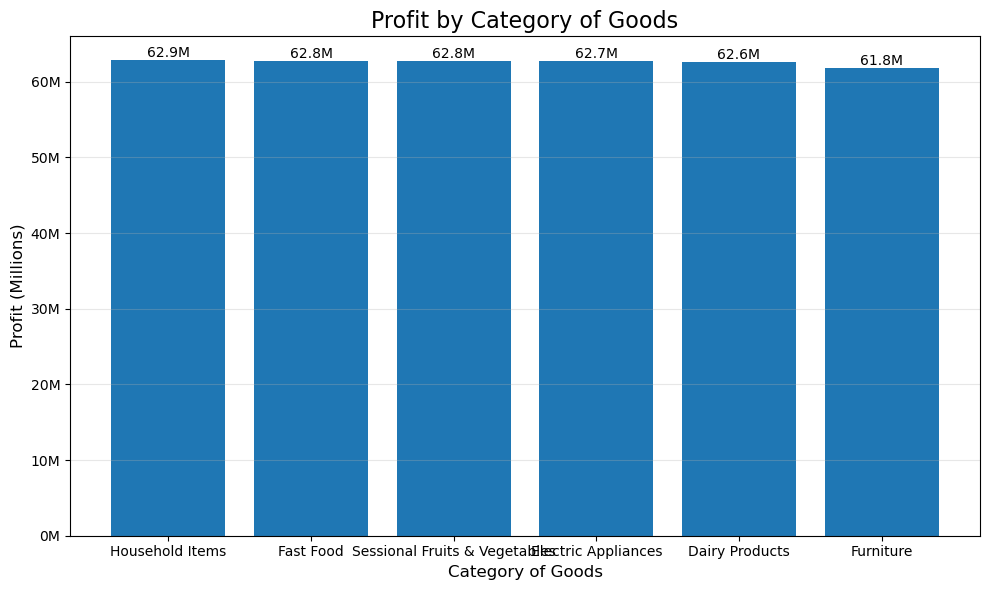

In [56]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    category_profit.index,
    category_profit.values
)

plt.title("Profit by Category of Goods", fontsize=16)
plt.xlabel("Category of Goods", fontsize=12)
plt.ylabel("Profit (Millions)", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Profit by Customer Segment


In [57]:
segment_profit = df.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

segment_profit

Segment
Consumer     1.877798e+08
Corporate    1.877507e+08
Name: Profit, dtype: float64

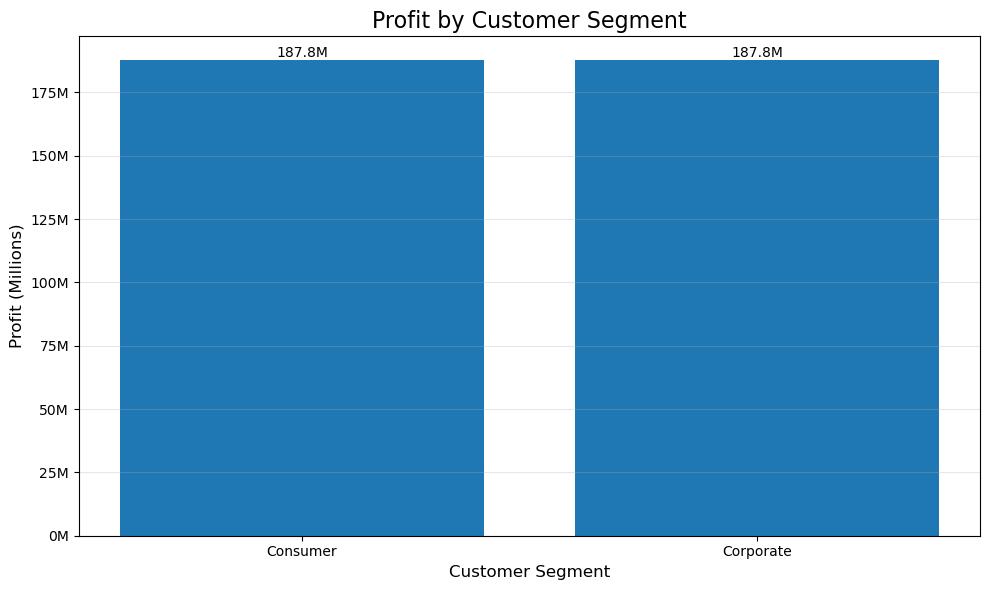

In [58]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    segment_profit.index,
    segment_profit.values
)

plt.title("Profit by Customer Segment", fontsize=16)
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Profit (Millions)", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Discount vs Profit Analysis


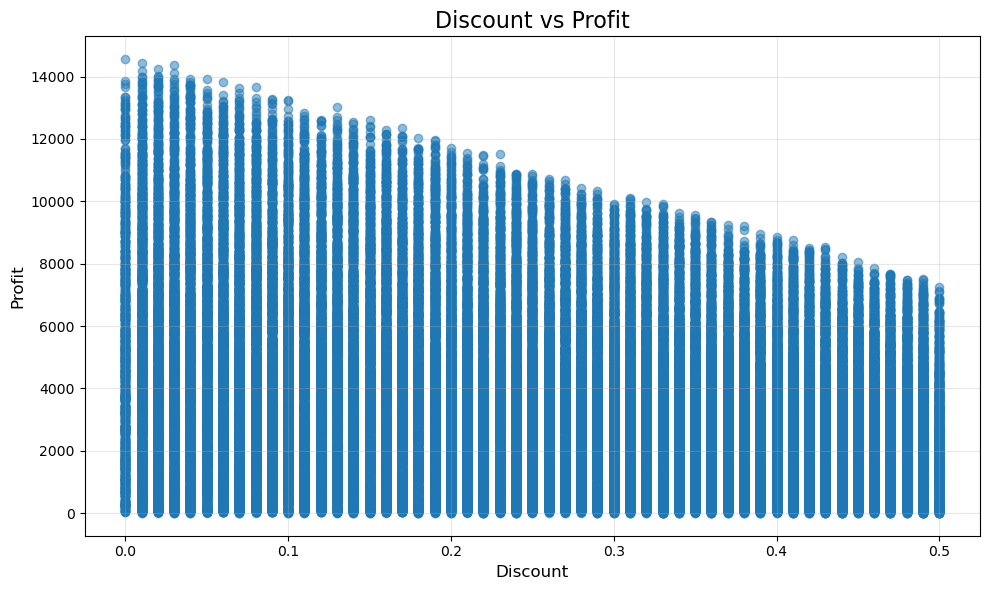

In [59]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit", fontsize=16)
plt.xlabel("Discount", fontsize=12)
plt.ylabel("Profit", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Top 10 Most Profitable Products


In [60]:
top_profit_products = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)

top_profit_products

Product Name
Beds - 120             77643.63
Mangoes - 912          70078.99
Refrigerators - 538    67496.63
Butter - 951           67379.88
Refrigerators - 338    66765.54
Microwaves - 157       66256.98
Apples - 425           65969.62
Microwaves - 808       63624.38
Refrigerators - 709    63501.42
Mops - 847             62670.68
Name: Profit, dtype: float64

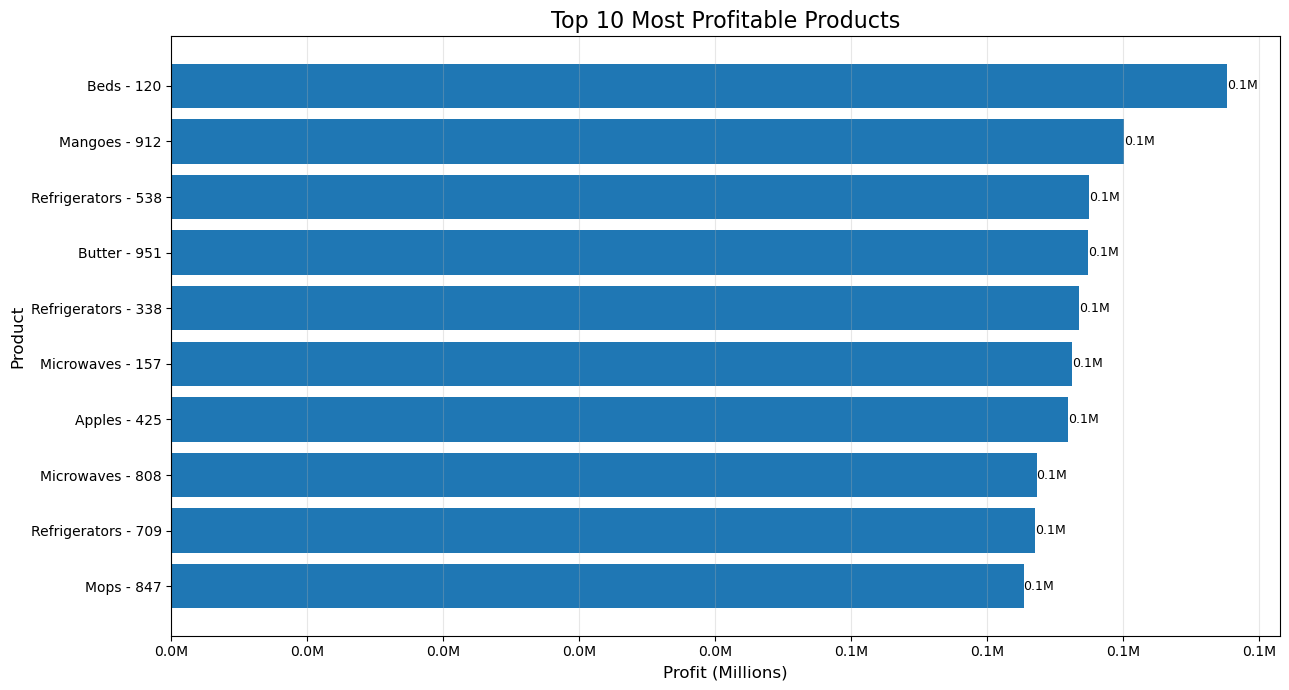

In [61]:
plt.figure(figsize=(13,7))

bars = plt.barh(
    top_profit_products.index,
    top_profit_products.values
)

plt.title("Top 10 Most Profitable Products", fontsize=16)
plt.xlabel("Profit (Millions)", fontsize=12)
plt.ylabel("Product", fontsize=12)

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
)

plt.gca().invert_yaxis()

for bar in bars:

    width = bar.get_width()

    plt.text(
        width,
        bar.get_y()+bar.get_height()/2,
        f"{width/1e6:.1f}M",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Bottom 10 Products by Profit


In [62]:
bottom_profit_products = df.groupby("Product Name")["Profit"].sum().sort_values().head(10)

bottom_profit_products

Product Name
Cheese - 665                9.93
Washing Machines - 290     21.50
Fans - 426                 36.18
Mops - 309                 47.38
Refrigerators - 550        48.96
Sofas - 378                70.97
Pizzas - 223               81.29
Fans - 766                 81.50
Tables - 682               95.83
Microwaves - 365          105.52
Name: Profit, dtype: float64

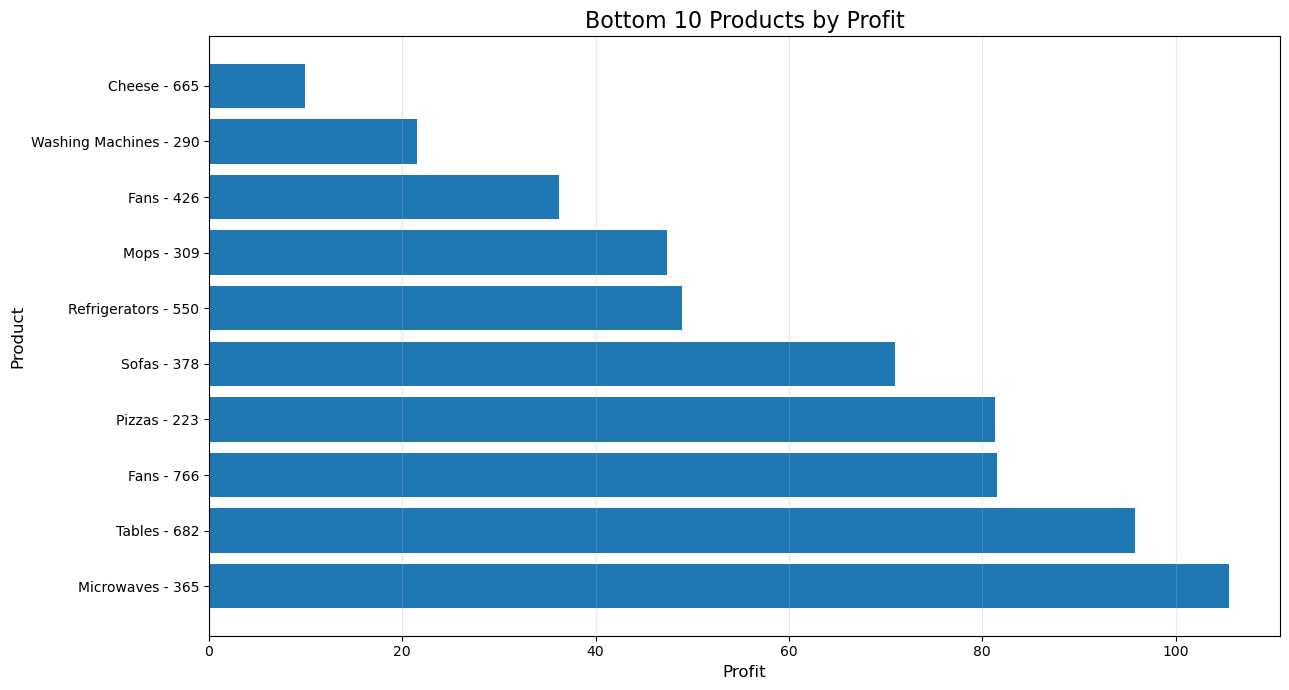

In [63]:
plt.figure(figsize=(13,7))

bars = plt.barh(
    bottom_profit_products.index,
    bottom_profit_products.values
)

plt.title("Bottom 10 Products by Profit", fontsize=16)
plt.xlabel("Profit", fontsize=12)
plt.ylabel("Product", fontsize=12)

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Customers by Age Group


In [64]:
age_group_count = df.groupby("Age Group")["Customer ID"].nunique().sort_index()

age_group_count

Age Group
18-25    11548
26-35    14500
36-45    14529
46-60    21784
60+      22991
<18      14648
Name: Customer ID, dtype: int64

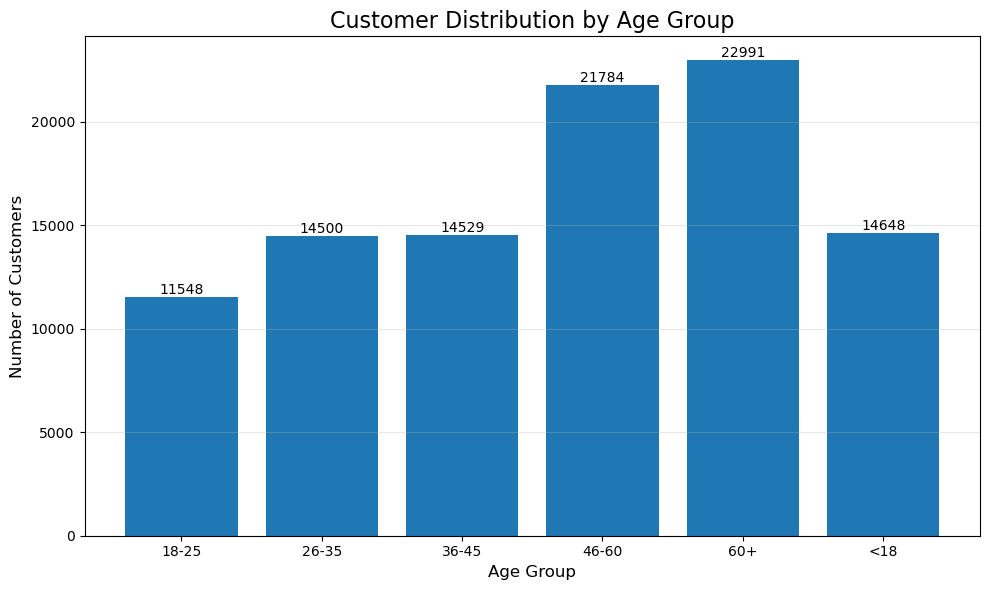

In [65]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    age_group_count.index.astype(str),
    age_group_count.values
)

plt.title("Customer Distribution by Age Group", fontsize=16)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Sales by Age Group


In [66]:
age_sales = df.groupby("Age Group")["Sales"].sum().sort_index()

age_sales

Age Group
18-25    2.906697e+08
26-35    3.637777e+08
36-45    3.630871e+08
46-60    5.465991e+08
60+      5.735478e+08
<18      3.707596e+08
Name: Sales, dtype: float64

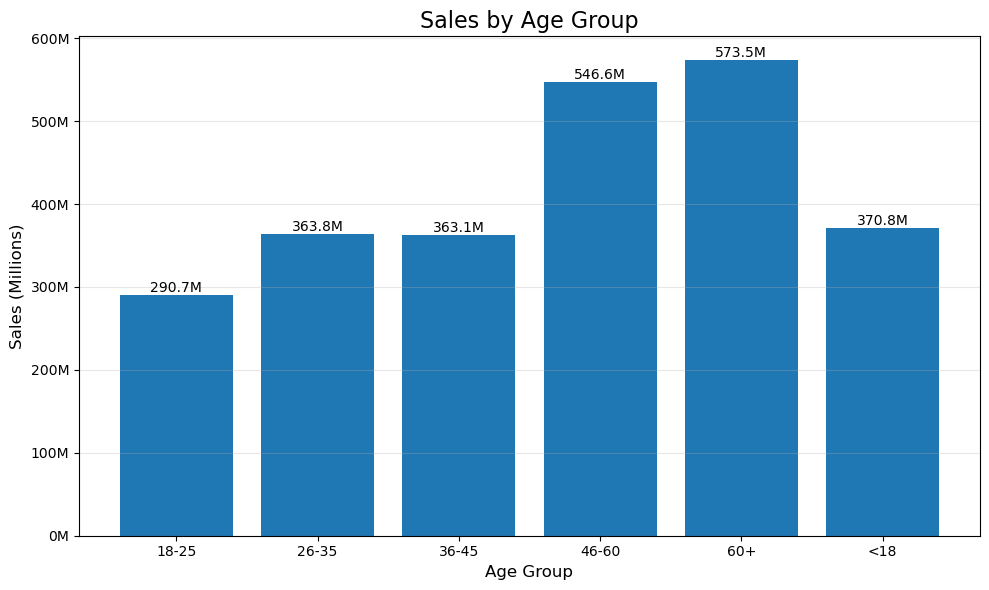

In [67]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    age_sales.index.astype(str),
    age_sales.values
)

plt.title("Sales by Age Group", fontsize=16)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Sales (Millions)", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Profit by Age Group


In [68]:
age_profit = df.groupby("Age Group")["Profit"].sum().sort_index()

age_profit

Age Group
18-25    43742876.63
26-35    54269423.91
36-45    54043311.51
46-60    81882287.25
60+      85773268.68
<18      55819343.45
Name: Profit, dtype: float64

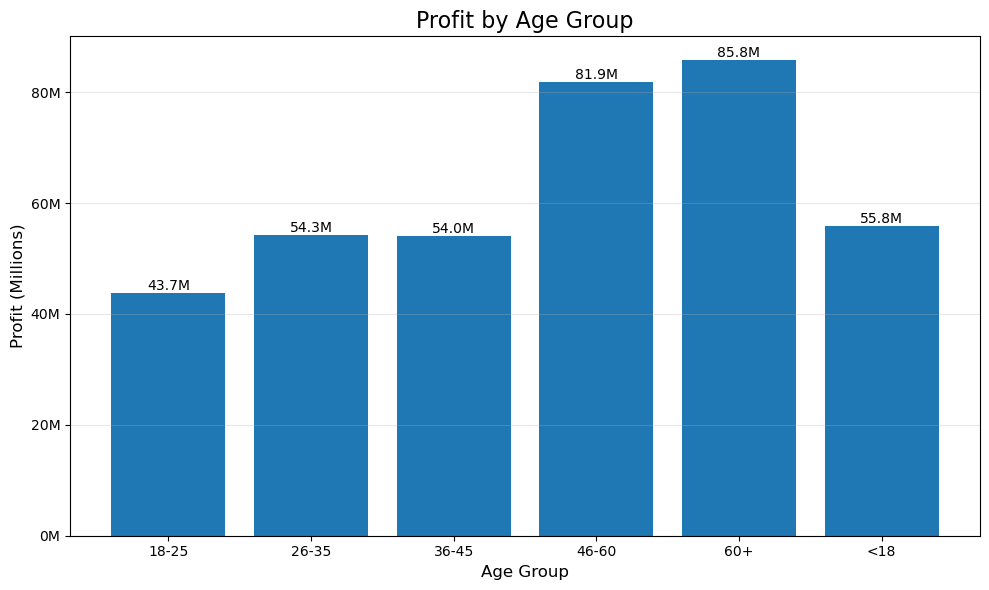

In [69]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    age_profit.index.astype(str),
    age_profit.values
)

plt.title("Profit by Age Group", fontsize=16)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Profit (Millions)", fontsize=12)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Average Selling Price by Age Group


In [70]:
age_asp = df.groupby("Age Group")["Average Selling Price"].mean().sort_index()

age_asp

Age Group
18-25    7413.804339
26-35    7352.217589
36-45    7413.021024
46-60    7320.488675
60+      7328.918367
<18      7508.778299
Name: Average Selling Price, dtype: float64

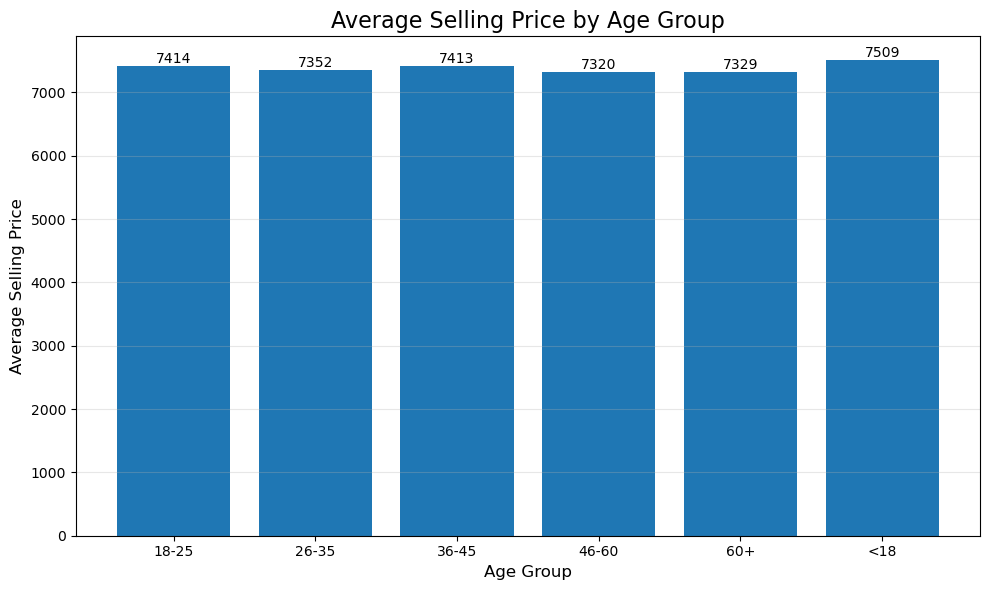

In [71]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    age_asp.index.astype(str),
    age_asp.values
)

plt.title("Average Selling Price by Age Group", fontsize=16)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Average Selling Price", fontsize=12)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Ship Mode Performance


In [72]:
ship_sales = df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)

ship_sales

Ship Mode
First Class       6.283755e+08
Same Day          6.272023e+08
Second Class      6.271439e+08
Standard Class    6.257193e+08
Name: Sales, dtype: float64

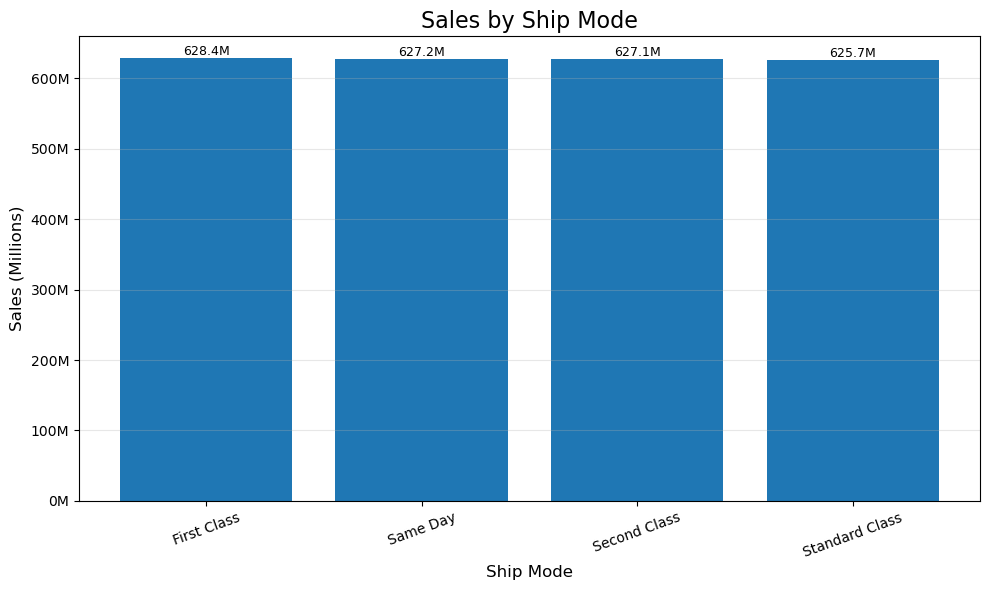

In [73]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    ship_sales.index,
    ship_sales.values
)

plt.title("Sales by Ship Mode", fontsize=16)
plt.xlabel("Ship Mode", fontsize=12)
plt.ylabel("Sales (Millions)", fontsize=12)

plt.xticks(rotation=20)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Average Delivery Days by Ship Mode


In [74]:
delivery = df.groupby("Ship Mode")["Delivery Days"].mean().sort_values()

delivery

Ship Mode
Second Class      3.973340
Same Day          3.988523
First Class       3.999482
Standard Class    4.002843
Name: Delivery Days, dtype: float64

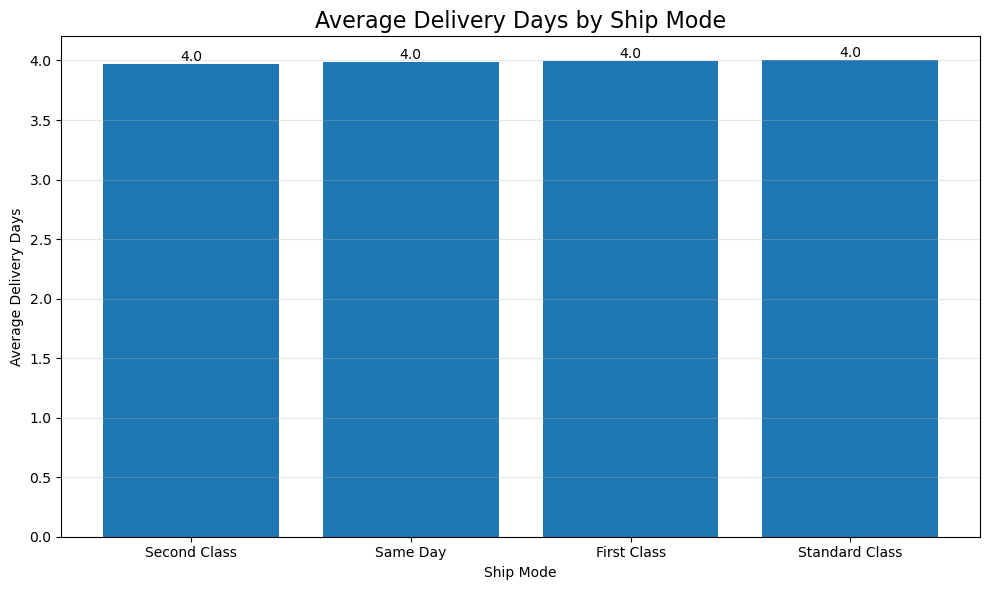

In [75]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    delivery.index,
    delivery.values
)

plt.title("Average Delivery Days by Ship Mode", fontsize=16)
plt.xlabel("Ship Mode")
plt.ylabel("Average Delivery Days")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Top 10 Sub-Categories


In [76]:
sub_category = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)

sub_category

Sub-Category
Mops                1.095685e+08
Carrots             1.075179e+08
Milk                1.058201e+08
Microwaves          1.058080e+08
Pizzas              1.057033e+08
Sofas               1.055018e+08
Burgers             1.053565e+08
Cheese              1.053360e+08
Refrigerators       1.051124e+08
Washing Machines    1.049020e+08
Name: Sales, dtype: float64

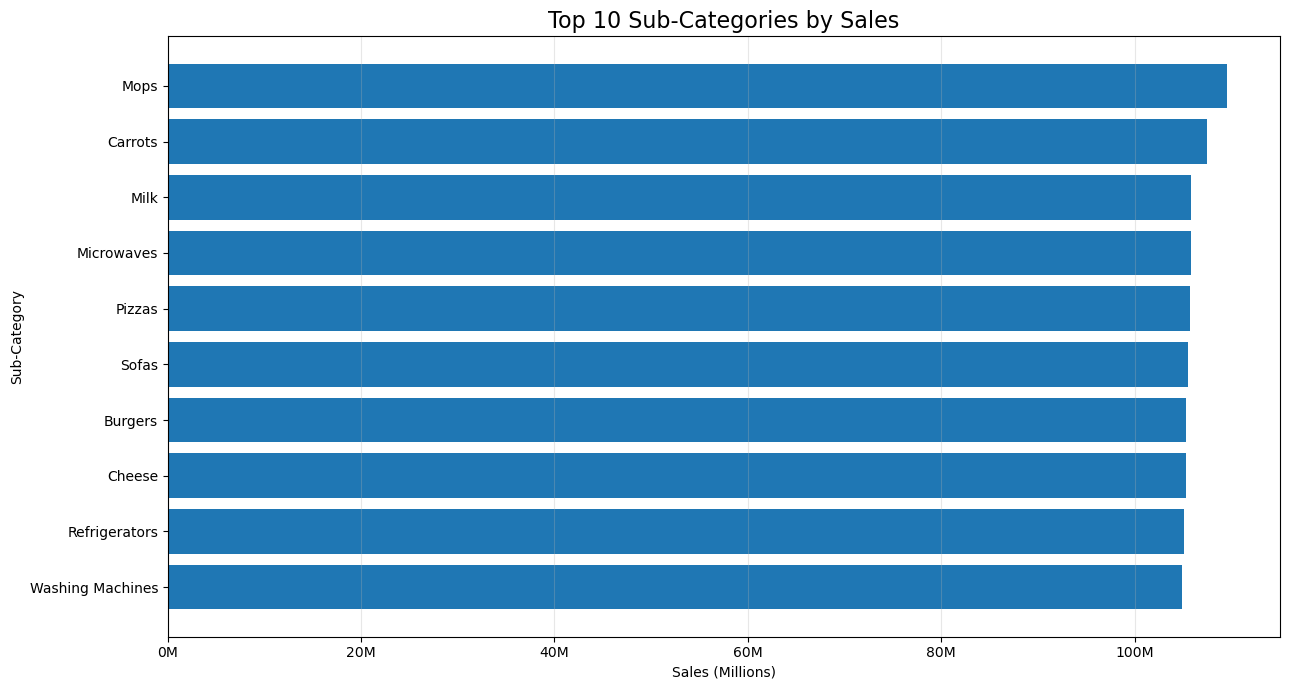

In [77]:
plt.figure(figsize=(13,7))

bars = plt.barh(
    sub_category.index,
    sub_category.values
)

plt.title("Top 10 Sub-Categories by Sales", fontsize=16)

plt.xlabel("Sales (Millions)")
plt.ylabel("Sub-Category")

plt.gca().invert_yaxis()

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M")
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Quantity Sold by Category


In [78]:
quantity = df.groupby("Category of Goods")["Quantity"].sum().sort_values(ascending=False)

quantity

Category of Goods
Household Items                  92038
Sessional Fruits & Vegetables    91921
Electric Appliances              91902
Fast Food                        91837
Dairy Products                   91026
Furniture                        90652
Name: Quantity, dtype: int64

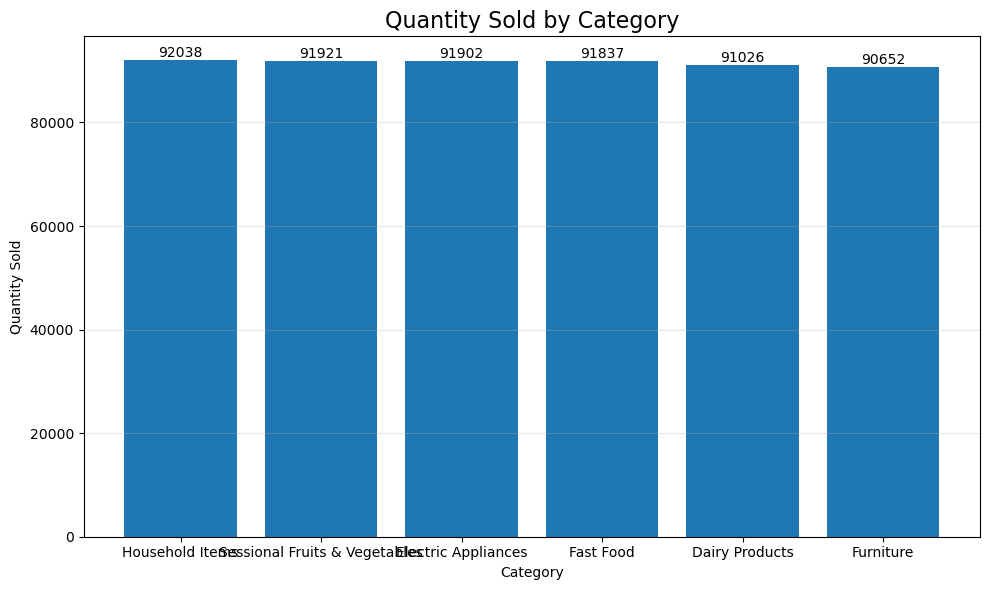

In [79]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    quantity.index,
    quantity.values
)

plt.title("Quantity Sold by Category", fontsize=16)

plt.xlabel("Category")

plt.ylabel("Quantity Sold")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [81]:
df.to_csv("../data/cleanned/cleaned_sales_data.csv", index=False)